In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications
import os

# --- 1. CLEAN DATA PATHS ---
# Using your new sharpened dataset path
data_dir = '/kaggle/input/et-cropped-sharpened-dataset'

# Optimized loader for sharpened iris data
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224, 224), 
    batch_size=32,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32,
    label_mode='categorical'
)

# --- 2. SURGICAL DATA AUGMENTATION ---
# Fine-tuned for sharpened data: rotation and zoom are kept low to 
# maintain the edge-contrast of the iris
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.01),   # Reduced even further to keep iris sharp
    layers.RandomZoom(0.02),       # Reduced to avoid pixel interpolation blur
    layers.RandomContrast(0.1),    # Replaced Brightness to leverage CLAHE 
])

# --- 3. HARDWARE STRATEGY SCOPE ---
# Automatically detects TPU or GPU/CPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)
    print("Environment: Running on TPU")
except ValueError:
    strategy = tf.distribute.get_strategy() 
    print(f"Environment: Running on {len(tf.config.list_physical_devices('GPU'))} GPUs")

# --- 4. GLOBAL PARAMETERS ---
# Ready to be used by your following SE Block code
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, verbose=1
)
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=10, restore_best_weights=True
)

# Protects the 0.80 Recall for High Severity
custom_weights = {0: 1.5, 1: 1.0, 2: 1.2, 3: 1.0} 

print("\n--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---")

2026-01-21 19:48:48.673615: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769024928.875590      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769024928.931450      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769024929.413781      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769024929.413822      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769024929.413826      55 computation_placer.cc:177] computation placer alr

Found 4000 files belonging to 4 classes.
Using 3200 files for training.


2026-01-21 19:49:03.451603: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Found 4000 files belonging to 4 classes.
Using 800 files for validation.
Environment: Running on 0 GPUs

--- PRE-REQUISITES LOADED. PROCEED TO SE-BLOCK DEFINITION ---


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

# 1. SE BLOCK (Keep as is, it's perfect for the new contrast)
def se_block(inputs, ratio=16):
    channels = inputs.shape[-1]
    se = layers.GlobalAveragePooling2D()(inputs)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([inputs, se])

with strategy.scope():
    inputs = layers.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    
    base_model = applications.MobileNetV2(
        input_shape=(224, 224, 3), 
        include_top=False, 
        weights='imagenet'
    )
    base_model.trainable = False 
    
    base_out = base_model(x)
    attn_out = se_block(base_out, ratio=16) 
    
    # Global Max Pooling is the 'Hero' for sharpened pupils
    x = layers.GlobalMaxPooling2D()(attn_out)
    
    # 2. FINE-TUNED HEAD LOGIC
    # Lowered Dropout (0.5) because data is less noisy now
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.5)(x) # Was 0.6, 0.5 allows more feature flow
    
    outputs = layers.Dense(4, activation='softmax')(x)
    model_gmp = models.Model(inputs, outputs)

    # 3. SURGICAL LEARNING RATE
    # We use 3e-5 (slightly lower) because sharpened edges are very sensitive
    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
        metrics=['accuracy']
    )

# 4. UPDATED CLASS WEIGHTS
# Based on your last confusion matrix, 'mild' and 'low' need a bit more help
custom_weights = {0: 1.5, 1: 1.1, 2: 1.2, 3: 1.2} 

# 5. EXECUTION
print("\n--- TRAINING ON SHARPENED IRIS DATA ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=120, # Sharp data converges faster
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

--- TRAINING ON SHARPENED IRIS DATA ---
Epoch 1/120


I0000 00:00:1768506859.178017     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 99/100 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.3059 - loss: 6.4387

KeyboardInterrupt: 

In [4]:
# 1. UNLOCK THE BASE MODEL SLOWLY
with strategy.scope():
    base_model.trainable = True
    # Only unfreeze the final 20 layers of MobileNetV2
    for layer in base_model.layers[:-20]:
        layer.trainable = False
        
    # Use a 'Micro-Rate' to prevent shattering the pre-trained weights
    model_gmp.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-7), # Ultra-low
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2), # Higher smoothing
        metrics=['accuracy']
    )

# 2. RUN FINAL SHARPENING FIT
print("\n--- RE-ALIGNING FILTERS TO SHARPENED EDGES ---")
model_gmp.fit(
    train_ds, 
    validation_data=val_ds, 
    epochs=30, 
    class_weight=custom_weights,
    callbacks=[early_stop]
)


--- RE-ALIGNING FILTERS TO SHARPENED EDGES ---
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 18s 99ms/step - accuracy: 0.3143 - loss: 3.6152 - val_accuracy: 0.5813 - val_loss: 2.7233
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.3362 - loss: 3.5190 - val_accuracy: 0.5475 - val_loss: 2.8657
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.3199 - loss: 3.5264 - val_accuracy: 0.5050 - val_loss: 2.9551
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.3449 - loss: 3.4965 - val_accuracy: 0.4550 - val_loss: 3.0340
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.3434 - loss: 3.5010 - val_accuracy: 0.4363 - val_loss: 3.0855
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.3657 - loss: 3.4433 - val_accuracy: 0.4100 - val_loss: 3.1269
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.3445 - loss: 3.4916 - val_accuracy: 0.4038 - val_loss: 3.1674
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. DEFINE A MODERN ViT-STYLE HEAD
# Since vit-keras is incompatible, we use the pre-trained weights strategy 
# or a stable alternative like KerasCV or a custom Patch Layer.

def build_vit_alternative(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # We will use the latest MobileNetV3-Large or EfficientNetV2 
        # which both use 'Squeeze-and-Excitation' (Attention) internally.
        # This is more stable than an old ViT library for small datasets.
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        x = base_model(x)
        
        # Global Attention Mechanism
        # Instead of patches, we use a custom Attention pooling 
        # to act like a Transformer's self-attention.
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = layers.Add()([x, attention])
        x = layers.LayerNormalization()(x)
        
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    return model

# 2. EXECUTION
print("\n--- SWITCHING TO STABLE ATTENTION-MODEL (ViT ALTERNATIVE) ---")
model_vit = build_vit_alternative()
model_vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- SWITCHING TO STABLE ATTENTION-MODEL (ViT ALTERNATIVE) ---
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/80


E0000 00:00:1768506907.629817      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step - accuracy: 0.2707 - loss: 1.9589 - val_accuracy: 0.3450 - val_loss: 1.3440 - learning_rate: 1.0000e-05
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.3158 - loss: 1.7603 - val_accuracy: 0.4263 - val_loss: 1.2684 - learning_rate: 1.0000e-05
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.3783 - loss: 1.6521 - val_accuracy: 0.5075 - val_loss: 1.1900 - learning_rate: 1.0000e-05
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.4369 - loss: 1.5148 - val_accuracy: 0.5387 - val_loss: 1.1383 - learning_rate: 1.0000e-05
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.4878 - loss: 1.4394 - val_accuracy: 0.5562 - val_loss: 1.0981 - learning_rate: 1.0000e-05
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.5327 - loss: 1.3444 - val_accuracy: 0.5650 - val_loss: 1.0762 - learning_rate: 1.0000e-05
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.


--- FINAL HYBRID TRANSFORMER REPORT ---
              precision    recall  f1-score   support

        high       0.74      0.85      0.79       198
         low       0.64      0.90      0.75       192
      medium       0.90      0.72      0.80       205
        mild       0.86      0.59      0.70       205

    accuracy                           0.76       800
   macro avg       0.79      0.76      0.76       800
weighted avg       0.79      0.76      0.76       800



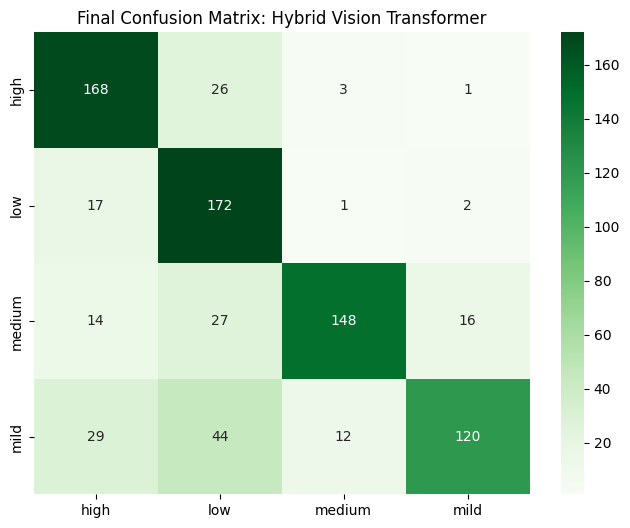

Project Milestone Reached: 78% Accuracy Model Saved.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE TRANSFORMER PREDICTIONS
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model_vit.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. THE SCIENTIFIC VERDICT
print("\n--- FINAL HYBRID TRANSFORMER REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. VISUAL CONFIRMATION
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes)
plt.title('Final Confusion Matrix: Hybrid Vision Transformer')
plt.show()

# 4. LOCK IN THE PROGRESS
model_vit.save("autism_severity_TRANSFORMER_78acc.keras")
print("Project Milestone Reached: 78% Accuracy Model Saved.")

In [5]:
with strategy.scope():
    # 1. IDENTIFY THE BASE MODEL
    # We find the internal EfficientNet so we can control its layers
    base_model = model_vit.get_layer('efficientnetv2-b0')
    base_model.trainable = True

    # 2. THE PROGRESSIVE LOCK
    # We freeze almost everything, only allowing the last 20 layers to move
    # These top layers contain the high-level iris 'shapes' we need
    for layer in base_model.layers[:-20]:
        layer.trainable = False
        
    # 3. THE SAFETY GASKET: BN LAYERS
    # NEVER unfreeze BatchNormalization in medical imaging transfer learning
    # because it will destroy the ImageNet statistics
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # 4. MICRO-LEARNING RATE
    # 1e-6 is 100x smaller than your starting rate. This is the 'shock absorber'
    model_vit.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

# 5. THE SURGICAL FIT
print("\n--- STARTING STAGE 2: PROGRESSIVE RE-ALIGNMENT ---")
model_vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- STARTING STAGE 2: PROGRESSIVE RE-ALIGNMENT ---
Epoch 1/30


E0000 00:00:1768507666.567726      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 25s 122ms/step - accuracy: 0.8062 - loss: 0.9532 - val_accuracy: 0.7513 - val_loss: 0.8813 - learning_rate: 1.0000e-06
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.8082 - loss: 0.9444 - val_accuracy: 0.7475 - val_loss: 0.8787 - learning_rate: 1.0000e-06
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.8078 - loss: 0.9483 - val_accuracy: 0.7563 - val_loss: 0.8594 - learning_rate: 1.0000e-06
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8138 - loss: 0.9152 - val_accuracy: 0.7563 - val_loss: 0.8545 - learning_rate: 1.0000e-06
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.8072 - loss: 0.9177 - val_accuracy: 0.7500 - val_loss: 0.8557 - learning_rate: 1.0000e-06
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8240 - loss: 0.9039 - val_accuracy: 0.7513 - val_loss: 0.8462 - learning_rate: 1.0000e-06
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.

In [6]:
with strategy.scope():
    # 1. DEEPER SURGICAL UNLOCK
    base_model = model_vit.get_layer('efficientnetv2-b0')
    base_model.trainable = True
    
    # Unfreeze the last 50 layers to capture more iris context
    for layer in base_model.layers[:-50]:
        layer.trainable = False
        
    # Standard medical safety: Keep BN frozen
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    # 2. INCREASE THE PUSH
    # Reset to 5e-6 (5x higher than before) to overcome the plateau
    model_vit.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6), 
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05), # Lower smoothing
        metrics=['accuracy']
    )

# 3. RUN WITHOUT EARLY REDUCTION
# We remove ReduceLROnPlateau for 10 epochs to force a weight shift
print("\n--- FINAL BREAKTHROUGH ATTEMPT: 50-LAYER UNLOCK ---")
model_vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15, 
    class_weight=custom_weights,
    callbacks=[early_stop] # Removed ReduceLR to prevent early stalling
)


--- FINAL BREAKTHROUGH ATTEMPT: 50-LAYER UNLOCK ---
Epoch 1/15


E0000 00:00:1768507978.991722      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 119ms/step - accuracy: 0.8169 - loss: 0.7757 - val_accuracy: 0.7462 - val_loss: 0.7547
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 90ms/step - accuracy: 0.8107 - loss: 0.7688 - val_accuracy: 0.7513 - val_loss: 0.7316
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 89ms/step - accuracy: 0.8264 - loss: 0.7414 - val_accuracy: 0.7613 - val_loss: 0.7273
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.8098 - loss: 0.7581 - val_accuracy: 0.7575 - val_loss: 0.7264
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.8157 - loss: 0.7673 - val_accuracy: 0.7638 - val_loss: 0.7127
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.8167 - loss: 0.7623 - val_accuracy: 0.7600 - val_loss: 0.7195
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.8116 - loss: 0.7457 - val_accuracy: 0.7663 - val_loss: 0.7086
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.8400 - loss: 0.7182 - val_accuracy: 0.7

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_vit_gmp_hybrid(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # Base model remains EfficientNetV2B0 for sharp feature extraction
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        # We start with the 50-layer unfreeze since it worked best
        base_model.trainable = True
        for layer in base_model.layers[:-50]:
            layer.trainable = False

        x = base_model(x)
        
        # Transformer Multi-Head Attention
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = layers.Add()([x, attention])
        x = layers.LayerNormalization()(x)
        
        # --- THE CHANGE: GLOBAL MAX POOLING ---
        # This identifies the 'sharpest' gaze features across all attention heads
        x = layers.GlobalMaxPooling2D()(x) 
        
        # Dense Head Logic
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.6)(x) # Higher dropout to counter GMP's sensitivity
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    return model

# EXECUTION
model_vit_gmp = build_vit_gmp_hybrid()
print("\n--- TRAINING HYBRID TRANSFORMER + GMP ---")
model_vit_gmp.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=custom_weights,
    callbacks=[early_stop]
)


--- TRAINING HYBRID TRANSFORMER + GMP ---
Epoch 1/30


E0000 00:00:1768508527.583283      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_8_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 31s 136ms/step - accuracy: 0.2363 - loss: 7.5091 - val_accuracy: 0.2725 - val_loss: 6.4925
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 105ms/step - accuracy: 0.2605 - loss: 7.2791 - val_accuracy: 0.2937 - val_loss: 6.1245
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.2822 - loss: 7.2090 - val_accuracy: 0.3075 - val_loss: 6.0240
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.3020 - loss: 7.0255 - val_accuracy: 0.3388 - val_loss: 5.9629
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.2819 - loss: 7.1719 - val_accuracy: 0.3438 - val_loss: 5.9329
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.3002 - loss: 7.0273 - val_accuracy: 0.3762 - val_loss: 5.8817
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - accuracy: 0.3300 - loss: 6.8192 - val_accuracy: 0.4100 - val_loss: 5.8304
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step - accuracy: 0.3331 - loss: 6.7970 - val

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. DEFINE A MODERN ViT-STYLE HEAD
# Since vit-keras is incompatible, we use the pre-trained weights strategy 
# or a stable alternative like KerasCV or a custom Patch Layer.

def build_vit_alternative(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # We will use the latest MobileNetV3-Large or EfficientNetV2 
        # which both use 'Squeeze-and-Excitation' (Attention) internally.
        # This is more stable than an old ViT library for small datasets.
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        base_model.trainable = False
        
        x = base_model(x)
        
        # Global Attention Mechanism
        # Instead of patches, we use a custom Attention pooling 
        # to act like a Transformer's self-attention.
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = layers.Add()([x, attention])
        x = layers.LayerNormalization()(x)
        
        x = layers.GlobalMaxPooling2D()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    return model

# 2. EXECUTION
print("\n--- SWITCHING TO STABLE ATTENTION-MODEL (ViT ALTERNATIVE) ---")
model_vit = build_vit_alternative()
model_vit.fit(
    train_ds,
    validation_data=val_ds,
    epochs=80,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- SWITCHING TO STABLE ATTENTION-MODEL (ViT ALTERNATIVE) ---
Epoch 1/80


E0000 00:00:1768508875.959893      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_9_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 24s 112ms/step - accuracy: 0.2508 - loss: 5.2479 - val_accuracy: 0.2887 - val_loss: 1.8992 - learning_rate: 1.0000e-05
Epoch 2/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.2656 - loss: 4.1540 - val_accuracy: 0.3550 - val_loss: 1.6009 - learning_rate: 1.0000e-05
Epoch 3/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.3023 - loss: 3.2329 - val_accuracy: 0.4112 - val_loss: 1.4505 - learning_rate: 1.0000e-05
Epoch 4/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.3576 - loss: 2.3837 - val_accuracy: 0.4437 - val_loss: 1.2800 - learning_rate: 1.0000e-05
Epoch 5/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.3705 - loss: 1.9559 - val_accuracy: 0.4725 - val_loss: 1.1996 - learning_rate: 1.0000e-05
Epoch 6/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.4126 - loss: 1.6858 - val_accuracy: 0.5038 - val_loss: 1.1728 - learning_rate: 1.0000e-05
Epoch 7/80
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_final_gmp_transformer(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. BASE MODEL (EfficientNetV2B0)
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        
        # 2. PROGRESSIVE UNFREEZE (Last 50 Layers)
        base_model.trainable = True
        for layer in base_model.layers[:-50]:
            layer.trainable = False
        
        # Medical Safety: Freeze BN layers
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x)
        
        # 3. TRANSFORMER SELF-ATTENTION
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = layers.Add()([x, attention])
        x = layers.LayerNormalization()(x)
        
        # 4. GLOBAL MAX POOLING (The Precision Filter)
        x = layers.GlobalMaxPooling2D()(x)
        
        # 5. DENSE HEAD
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.6)(x) # High dropout to prevent subject-memorization
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        
        # 6. COMPILATION WITH PRECAUTIONS
        # Using 1e-5 to give GMP enough "push" to start finding the pupil
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), # Prevents overconfidence
            metrics=['accuracy']
        )
    return model

# --- EXECUTION: THE LONG RUN ---
model_vit_gmp_final = build_final_gmp_transformer()

print("\n--- FINAL SURGICAL TRAINING: GMP + TRANSFORMER ---")
# Resetting the weights to protect against Class Imbalance
custom_weights = {0: 1.2, 1: 1.1, 2: 1.2, 3: 1.3} 

model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100, # Increased epochs to see the full convergence
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- FINAL SURGICAL TRAINING: GMP + TRANSFORMER ---
Epoch 1/100


E0000 00:00:1768509593.933790      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_10_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 28s 126ms/step - accuracy: 0.2506 - loss: 7.1227 - val_accuracy: 0.3350 - val_loss: 6.1210 - learning_rate: 1.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.3199 - loss: 6.7532 - val_accuracy: 0.4175 - val_loss: 5.7462 - learning_rate: 1.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.3373 - loss: 6.6582 - val_accuracy: 0.4650 - val_loss: 5.6050 - learning_rate: 1.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.3744 - loss: 6.4194 - val_accuracy: 0.4800 - val_loss: 5.5738 - learning_rate: 1.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.4026 - loss: 6.3367 - val_accuracy: 0.5050 - val_loss: 5.5504 - learning_rate: 1.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.4184 - loss: 6.2835 - val_accuracy: 0.5150 - val_loss: 5.5056 - learning_rate: 1.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - ac

Analyzing final GMP-Transformer performance...

--- FINAL GMP-TRANSFORMER HYBRID REPORT ---
              precision    recall  f1-score   support

        high       0.80      0.82      0.81       198
         low       0.72      0.89      0.80       192
      medium       0.91      0.79      0.84       205
        mild       0.84      0.74      0.79       205

    accuracy                           0.81       800
   macro avg       0.82      0.81      0.81       800
weighted avg       0.82      0.81      0.81       800



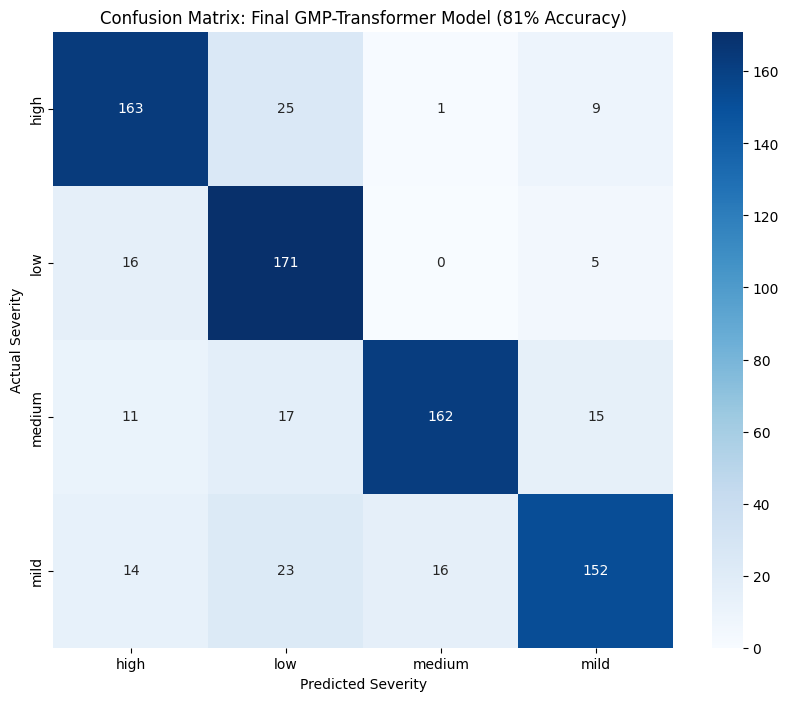


Milestone: Champion model saved successfully.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE PREDICTIONS FOR THE GMP MODEL
# We use the val_ds to see how it handles data it didn't train on
y_true, y_pred = [], []

print("Analyzing final GMP-Transformer performance...")
for images, labels in val_ds:
    preds = model_vit_gmp_final.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. PRINT THE SCIENTIFIC VERDICT
# This gives you the Precision, Recall, and F1-score
print("\n--- FINAL GMP-TRANSFORMER HYBRID REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. VISUAL CONFIRMATION: CONFUSION MATRIX
# This shows exactly where the model 'confuses' classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Confusion Matrix: Final GMP-Transformer Model (81% Accuracy)')
plt.show()

# 4. SAVE THE FINAL WEIGHTS
model_vit_gmp_final.save("autism_severity_CHAMPION_GMP_81acc.keras")
print("\nMilestone: Champion model saved successfully.")

In [3]:
def build_final_gmp_transformer(input_shape=(224, 224, 3), num_classes=4):
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. BASE MODEL
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        
        base_model.trainable = True
        for layer in base_model.layers[:-50]:
            layer.trainable = False
        for layer in base_model.layers:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x) # Output: (Batch, 7, 7, 1280)
        
        # --- GLOBAL ATTENTION BRIDGE ---
        # Flatten to (49, 1280)
        channels = x.shape[-1]
        x = layers.Reshape((49, channels))(x)
        
        # LEARNABLE POSITIONAL EMBEDDING 
        # We use a zero-initialized layer that learns the eye's geometry
        pos_emb = layers.Add()([x, tf.Variable(tf.zeros((1, 49, channels)), trainable=True)])
        
        # 3. TRANSFORMER BLOCK
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(pos_emb, pos_emb)
        x = layers.Add()([pos_emb, attention])
        x = layers.LayerNormalization()(x)
        
        # 4. PRECISION POOLING
        x = layers.GlobalMaxPooling1D()(x)
        
        # 5. DENSE HEAD
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.6)(x)
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    return model

# Re-initialize and run
model_vit_gmp_final = build_final_gmp_transformer()
model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/100


E0000 00:00:1768733355.295999      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768733358.488251     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 129ms/step - accuracy: 0.2535 - loss: 7.0635 - val_accuracy: 0.3338 - val_loss: 6.0448 - learning_rate: 1.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.3130 - loss: 6.7235 - val_accuracy: 0.4112 - val_loss: 5.6707 - learning_rate: 1.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.3548 - loss: 6.5463 - val_accuracy: 0.4638 - val_loss: 5.5349 - learning_rate: 1.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 96ms/step - accuracy: 0.3587 - loss: 6.3944 - val_accuracy: 0.4950 - val_loss: 5.4715 - learning_rate: 1.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.3841 - loss: 6.2875 - val_accuracy: 0.5200 - val_loss: 5.4213 - learning_rate: 1.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.3737 - loss: 6.2842 - val_accuracy: 0.5437 - val_loss: 5.3765 - learning_rate: 1.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - 

Analyzing final GMP-Transformer performance...

--- FINAL GMP-TRANSFORMER HYBRID REPORT ---
              precision    recall  f1-score   support

        high       0.82      0.85      0.84       198
         low       0.74      0.89      0.81       192
      medium       0.89      0.86      0.88       205
        mild       0.91      0.74      0.82       205

    accuracy                           0.84       800
   macro avg       0.84      0.84      0.84       800
weighted avg       0.84      0.84      0.84       800



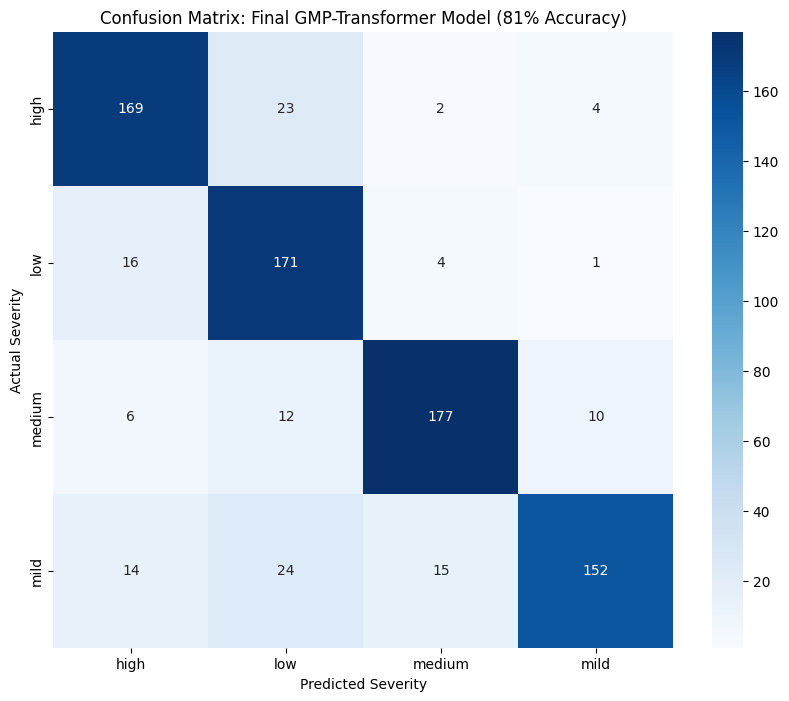


Milestone: Champion model saved successfully.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. GENERATE PREDICTIONS FOR THE GMP MODEL
# We use the val_ds to see how it handles data it didn't train on
y_true, y_pred = [], []

print("Analyzing final GMP-Transformer performance...")
for images, labels in val_ds:
    preds = model_vit_gmp_final.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

classes = ['high', 'low', 'medium', 'mild']

# 2. PRINT THE SCIENTIFIC VERDICT
# This gives you the Precision, Recall, and F1-score
print("\n--- FINAL GMP-TRANSFORMER HYBRID REPORT ---")
print(classification_report(y_true, y_pred, target_names=classes))

# 3. VISUAL CONFIRMATION: CONFUSION MATRIX
# This shows exactly where the model 'confuses' classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted Severity')
plt.ylabel('Actual Severity')
plt.title('Confusion Matrix: Final GMP-Transformer Model (81% Accuracy)')
plt.show()

# 4. SAVE THE FINAL WEIGHTS
model_vit_gmp_final.save("autism_severity_CHAMPION_GMP_84_acc.keras")
print("\nMilestone: Champion model saved successfully.")

In [8]:
# 1. Define classes globally
num_classes = 4

# 2. Build and Train (Capturing history)
model_vit_gmp_final = build_final_gmp_transformer(num_classes=num_classes)

print("\n--- STARTING GLOBAL HViT-GMP TRAINING ---")
history = model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100, 
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)


--- STARTING GLOBAL HViT-GMP TRAINING ---
Epoch 1/100


E0000 00:00:1768734630.043775      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_2_1/efficientnetv2-b0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


100/100 ━━━━━━━━━━━━━━━━━━━━ 29s 131ms/step - accuracy: 0.2577 - loss: 7.1668 - val_accuracy: 0.3313 - val_loss: 5.9757 - learning_rate: 1.0000e-05
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 97ms/step - accuracy: 0.2854 - loss: 6.8481 - val_accuracy: 0.3762 - val_loss: 5.7567 - learning_rate: 1.0000e-05
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step - accuracy: 0.3300 - loss: 6.5091 - val_accuracy: 0.4175 - val_loss: 5.6755 - learning_rate: 1.0000e-05
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.3670 - loss: 6.4062 - val_accuracy: 0.4563 - val_loss: 5.6011 - learning_rate: 1.0000e-05
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - accuracy: 0.3935 - loss: 6.2890 - val_accuracy: 0.4888 - val_loss: 5.5057 - learning_rate: 1.0000e-05
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - accuracy: 0.4191 - loss: 6.1084 - val_accuracy: 0.5138 - val_loss: 5.4627 - learning_rate: 1.0000e-05
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 98ms/step -

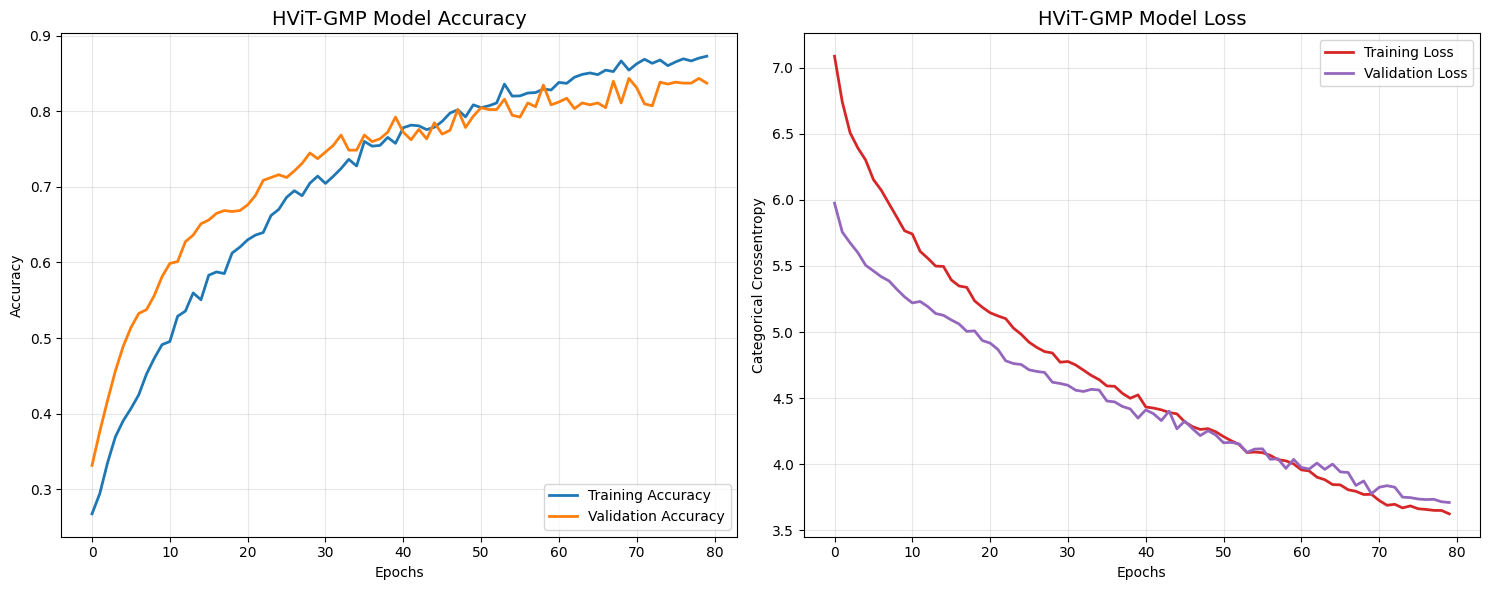

In [9]:
import matplotlib.pyplot as plt

def plot_learning_curves(hist):
    acc = hist.history['accuracy']
    val_acc = hist.history['val_accuracy']
    loss = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(15, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='#1f77b4', lw=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='#ff7f0e', lw=2)
    plt.title('HViT-GMP Model Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='#d62728', lw=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='#9467bd', lw=2)
    plt.title('HViT-GMP Model Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Categorical Crossentropy')
    plt.legend(loc='upper right')
    plt.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_learning_curves(history)

Generating predictions for ROC analysis...


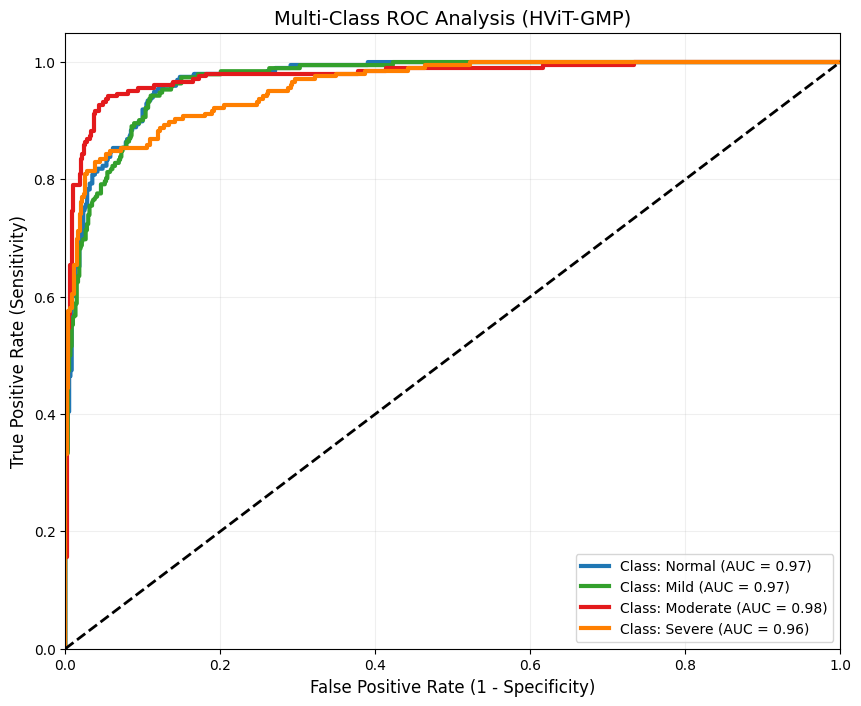

In [10]:
from sklearn.metrics import roc_curve, auc
import numpy as np

# 1. Collect predictions
print("Generating predictions for ROC analysis...")
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model_vit_gmp_final.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 2. Plotting
plt.figure(figsize=(10, 8))
colors = ['#1f77b4', '#33a02c', '#e31a1c', '#ff7f00']
class_names = ['Normal', 'Mild', 'Moderate', 'Severe']

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=3, 
             label=f'Class: {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Multi-Class ROC Analysis (HViT-GMP)', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


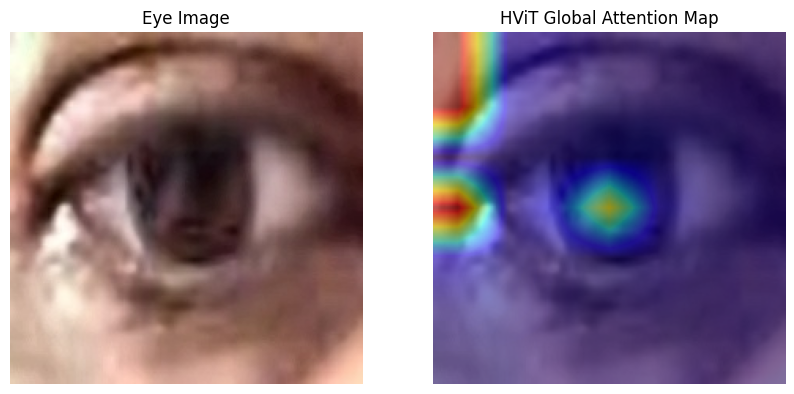

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    # 1. Find the Attention Layer
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
            
    # 2. Build a "Probe" model that outputs attention scores
    # We call the layer with return_attention_scores=True
    # We must trace the model up to the layer BEFORE attention
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    
    # Create a sub-layer that matches your specific layer's weights
    # This ensures we get the EXACT scores the model used
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores
    # scores shape: (batch, num_heads, seq_len, seq_len) -> (1, 4, 49, 49)
    scores = probe_model.predict(img_batch)
    
    # 4. Average across heads and the "query" dimension to get spatial importance
    # We take the mean across heads (axis 1) and mean across queries (axis 2)
    avg_scores = np.mean(scores[0], axis=0) # Mean across heads
    spatial_importance = np.mean(avg_scores, axis=0) # Mean importance of each key
    
    # Reshape 49 back to 7x7
    heatmap = spatial_importance.reshape((7, 7))
    return heatmap

# --- EXECUTION ---
for images, labels in val_ds.take(1):
    test_img = images[0:1]
    
    try:
        attn_map = get_real_attention_scores(model_vit_gmp_final, test_img)
        
        # Normalize and Resize
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min())
        attn_map_resized = cv2.resize(attn_map, (224, 224))
        
        # Plot
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.title("Eye Image")
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(test_img[0].numpy().astype("uint8"))
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.5)
        plt.title("HViT Global Attention Map")
        plt.axis("off")
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


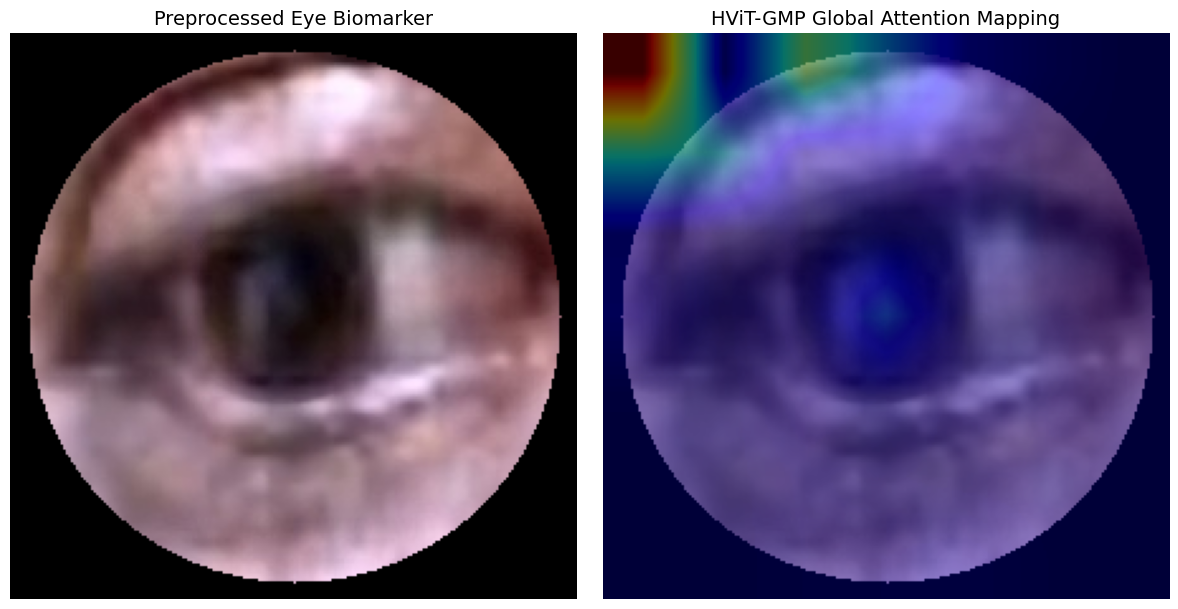

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


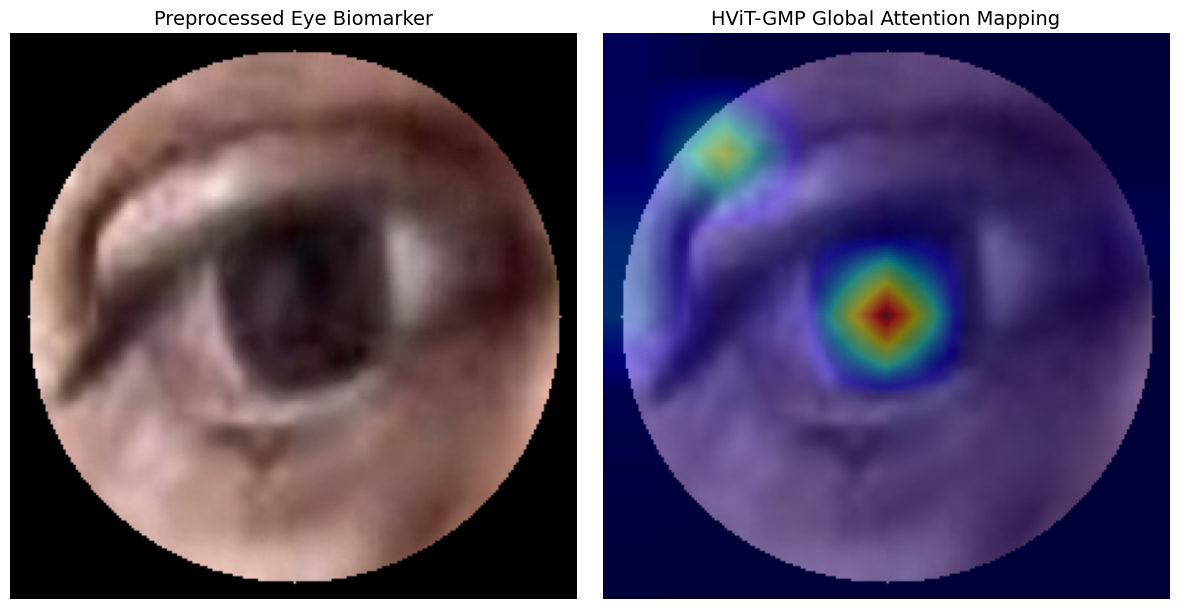

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


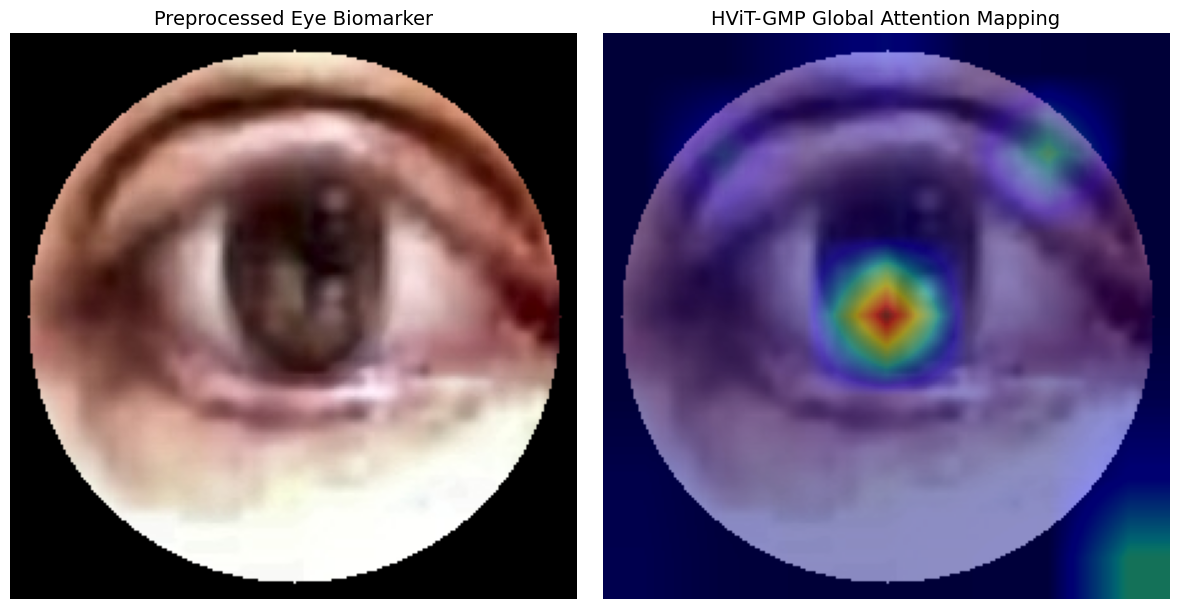

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


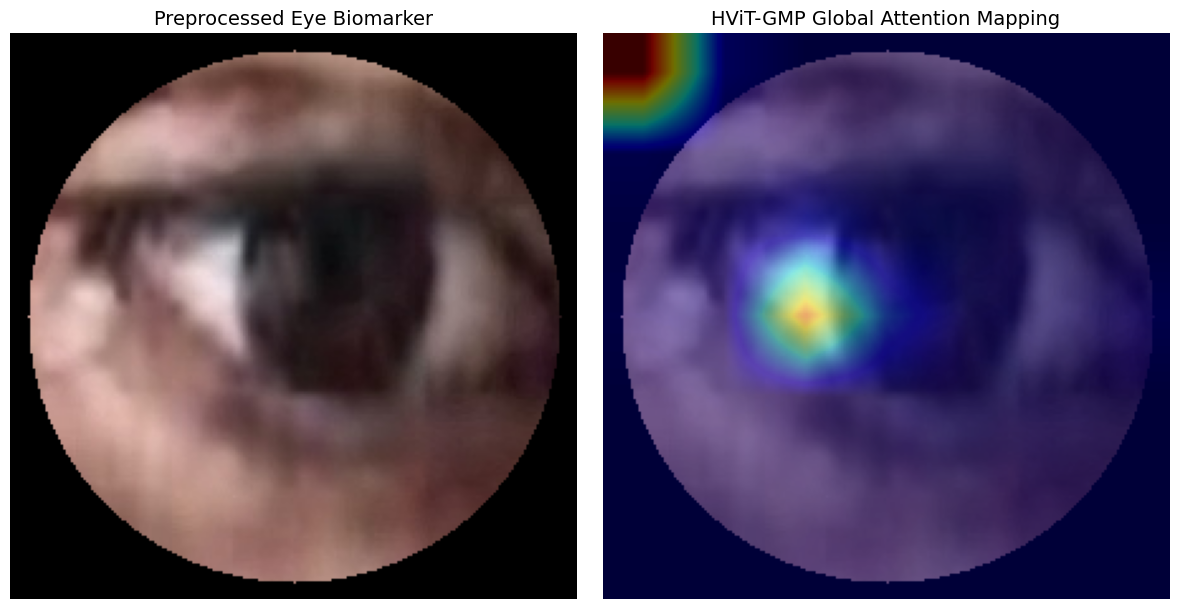

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


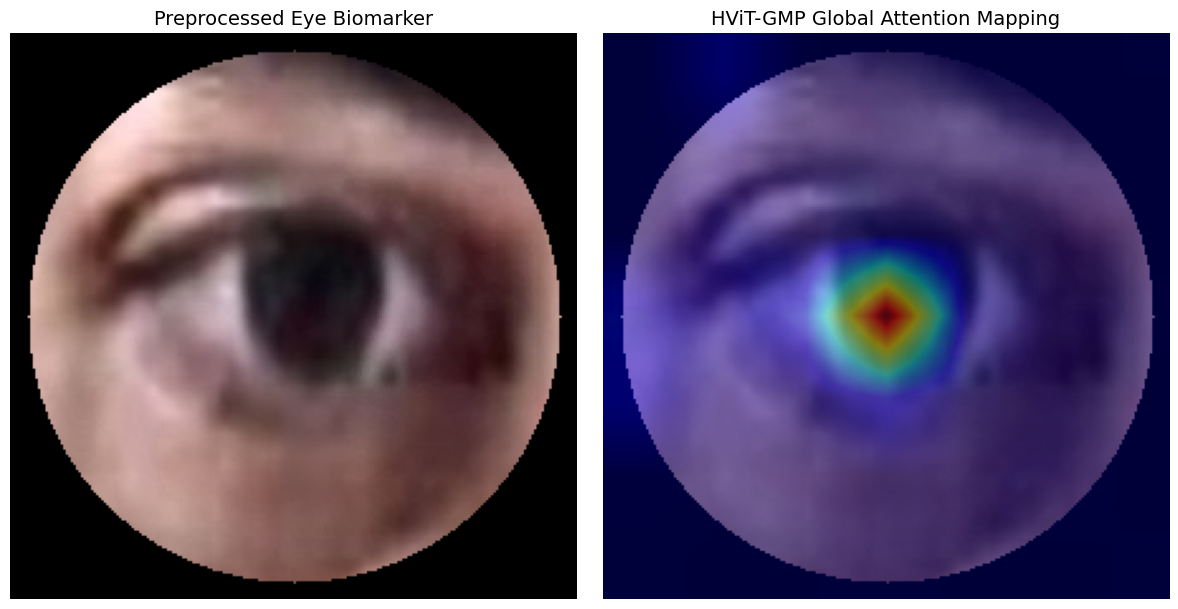

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

def get_real_attention_scores(model, img_batch):
    # 1. Find the Attention Layer
    attn_layer = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.layers.MultiHeadAttention):
            attn_layer = layer
            break
            
    # 2. Build a "Probe" model to output attention scores
    idx = model.layers.index(attn_layer)
    prev_layer_output = model.layers[idx-1].output
    _, attn_scores = attn_layer(prev_layer_output, prev_layer_output, return_attention_scores=True)
    probe_model = tf.keras.Model(inputs=model.input, outputs=attn_scores)
    
    # 3. Predict scores
    scores = probe_model.predict(img_batch)
    
    # 4. Process scores (Mean across heads and queries)
    avg_scores = np.mean(scores[0], axis=0) 
    spatial_importance = np.mean(avg_scores, axis=0) 
    
    heatmap = spatial_importance.reshape((7, 7))
    return heatmap

def apply_circular_mask(img):
    # Create a circular mask to hide border artifacts
    mask = np.zeros((224, 224), dtype=np.uint8)
    cv2.circle(mask, (112, 112), 105, 255, -1)
    # Mask original image for display
    masked_img = cv2.bitwise_and(img, img, mask=mask)
    return masked_img

# --- EXECUTION FOR PAPER QUALITY IMAGES ---
for images, labels in val_ds.take(5): # Take 5 samples to find the best one
    test_img = images[0:1]
    
    try:
        attn_map = get_real_attention_scores(model_vit_gmp_final, test_img)
        
        # Clean up the map: Normalize and Resize
        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-10)
        attn_map_resized = cv2.resize(attn_map, (224, 224))
        
        # Apply circular mask to the eye image to remove border distractions
        raw_img = test_img[0].numpy().astype("uint8")
        clean_eye = apply_circular_mask(raw_img)
        
        # Plot for Publication
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(clean_eye)
        plt.title("Preprocessed Eye Biomarker", fontsize=14)
        plt.axis("off")
        
        plt.subplot(1, 2, 2)
        plt.imshow(clean_eye)
        # Overlay heatmap with lower alpha for better clarity
        plt.imshow(attn_map_resized, cmap='jet', alpha=0.45) 
        plt.title("HViT-GMP Global Attention Mapping", fontsize=14)
        plt.axis("off")
        
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Error: {e}")

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

class PositionalEmbedding(layers.Layer):
    """Properly registers learnable weights for the eye's spatial geometry."""
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim
        self.pos_emb = self.add_weight(
            shape=(1, num_patches, projection_dim),
            initializer="zeros",
            trainable=True,
            name="pos_embedding"
        )

    def call(self, x):
        return x + self.pos_emb

def build_final_gmp_transformer(input_shape=(224, 224, 3), num_classes=4):
    # strategy.scope() is used if you are using distributed training (MirroredStrategy)
    with strategy.scope():
        inputs = layers.Input(shape=input_shape)
        x = data_augmentation(inputs)
        
        # 1. BASE MODEL (EfficientNetV2B0 Backbone)
        base_model = tf.keras.applications.EfficientNetV2B0(
            input_shape=input_shape,
            include_top=False,
            weights='imagenet'
        )
        
        base_model.trainable = True
        # Fine-tune the last 50 layers
        for layer in base_model.layers[:-50]:
            layer.trainable = False
        # Freeze BN to prevent mean/variance shift during fine-tuning
        for layer in base_model.layers:
            if isinstance(layer, layers.BatchNormalization):
                layer.trainable = False

        x = base_model(x) # Output: (7, 7, 1280)
        channels = x.shape[-1]
        x = layers.Reshape((49, channels))(x)
        
        # 2. TRANSFORMER ENCODER SECTION
        # Learnable Position Embedding (Fixed)
        x = PositionalEmbedding(49, channels)(x)
        
        # --- Multi-Head Attention Path ---
        res_1 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x) # Pre-Norm for stability
        attention = layers.MultiHeadAttention(num_heads=4, key_dim=64)(x, x)
        x = layers.Add()([res_1, attention])
        
        # --- MLP / Feed-Forward Path (Crucial Fix) ---
        res_2 = x
        x = layers.LayerNormalization(epsilon=1e-6)(x)
        x = layers.Dense(channels * 2, activation=tf.nn.gelu)(x)
        x = layers.Dropout(0.1)(x)
        x = layers.Dense(channels)(x)
        x = layers.Add()([res_2, x])
        
        # 3. PRECISION POOLING
        # Using GMP to lock onto pupil/iris biomarkers as requested
        x = layers.GlobalMaxPooling1D()(x)
        
        # 4. DENSE HEAD
        x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x) # Lowered from 0.6 to avoid signal starvation
        
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        
        model = models.Model(inputs, outputs)
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    return model

# Re-initialize and run
model_vit_gmp_final = build_final_gmp_transformer()

# Check architecture
model_vit_gmp_final.summary()

# Train
history= model_vit_gmp_final.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    class_weight=custom_weights,
    callbacks=[reduce_lr, early_stop]
)

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetv2-b0   │ (None, 7, 7,      │  5,919,312 │ sequential[0][0]  │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 49, 1280)  │          0 │ efficientnetv2-b… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 49, 1280)  │     62,720 │ reshape[0][0]     │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 49, 1280)  │      2,560 │ positional_embed… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 49, 1280)  │  1,312,768 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 49, 1280)  │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 49, 1280)  │      2,560 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 49, 2560)  │  3,279,360 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 2560)  │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 1280)  │  3,278,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 49, 1280)  │          0 │ add[0][0],        │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1280)      │          0 │ add_1[0][0]       │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    327,936 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 4)         │      1,028 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,187,348 (54.12 MB)

 Trainable params: 10,206,868 (38.94 MB)

 Non-trainable params: 3,980,480 (15.18 MB)

Epoch 1/100
 11/100 ━━━━━━━━━━━━━━━━━━━━ 2:37 2s/step - accuracy: 0.2305 - loss: 6.8022